# 08 — Richer acoustics + predict behavioral *content*

Two follow-ups after notebook 07:

1. **Richer features:** pitch contour (f0) + temporal dynamics (deltas, onset, spectral std) from wavs
2. **New target:** predict mean receiver behavior `(MI, BP, D)` — not consistency strength

Also re-test consistency prediction with the enriched feature set.

CV = GroupKFold by `Sender`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, MultiTaskElasticNetCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr
from pathlib import Path

np.random.seed(42)
N_SPLITS = 5
CHIRP = Path(r"D:\CHIRP")
DATA_PATH = CHIRP / "data" / "playback_data_combined.xlsx"
TEMPORAL_CSV = CHIRP / "analysis" / "outputs" / "features_temporal_pitch.csv"
OUT_DIR = CHIRP / "analysis" / "outputs"

sns.set_theme(style="whitegrid", context="notebook")

## 1. Load base + temporal/pitch features

In [2]:
df_raw = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
beh_cols = [
    "Receiver1MI", "Receiver1BP", "Receiver1D",
    "Receiver2MI", "Receiver2BP", "Receiver2D",
    "Receiver3MI", "Receiver3BP", "Receiver3D",
]
df = df_raw.dropna(subset=beh_cols).copy().reset_index(drop=True)

base_cols = (
    [f"mfcc{i}_mean" for i in range(1, 14)]
    + [f"mfcc{i}_std" for i in range(1, 14)]
    + [f"chroma{i}" for i in range(1, 13)]
    + ["zcr", "rms", "spectral_centroid"]
)

temporal = pd.read_csv(TEMPORAL_CSV)
df = df.merge(temporal, on=["Number", "FileName"], how="inner")
print(f"Merged rows: {len(df)} | temporal features file: {TEMPORAL_CSV}")

temporal_cols = [c for c in temporal.columns if c not in ("Number", "FileName")]
# Drop rows with missing f0 (rare)
df = df.dropna(subset=temporal_cols).reset_index(drop=True)
print(f"After dropna: {len(df)}")
print(f"Base feats: {len(base_cols)} | Temporal/pitch: {len(temporal_cols)} | Total: {len(base_cols)+len(temporal_cols)}")

all_feat_cols = base_cols + temporal_cols
X_base = df[base_cols].to_numpy(dtype=float)
X_rich = df[all_feat_cols].to_numpy(dtype=float)
groups = df["Sender"].to_numpy()

Merged rows: 307 | temporal features file: features_temporal_pitch.csv
After dropna: 307
Base feats: 41 | Temporal/pitch: 57 | Total: 98


## 2. Build targets: behavior content + consistency

In [3]:
# Behavior vectors (z-scored globally, same as nb05)
all_raw = np.vstack([
    df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy()
    for i in (1, 2, 3)
])
beh_scaler = StandardScaler().fit(all_raw)
R = np.zeros((len(df), 3, 3))
for i in (1, 2, 3):
    raw = df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy()
    R[:, i - 1, :] = beh_scaler.transform(raw)

Y_content = R.mean(axis=1)  # (n, 3) mean response content
df["y_MI"] = Y_content[:, 0]
df["y_BP"] = Y_content[:, 1]
df["y_D"] = Y_content[:, 2]


def pairwise_euc(vecs):
    pairs = [(0, 1), (0, 2), (1, 2)]
    return float(np.mean([np.linalg.norm(vecs[i] - vecs[j]) for i, j in pairs]))


y_euc = np.array([pairwise_euc(R[i]) for i in range(len(df))])
df["mean_euclidean"] = y_euc
print("Y_content shape", Y_content.shape)
print(df[["y_MI", "y_BP", "y_D", "mean_euclidean"]].describe().round(3))

Y_content shape (307, 3)
          y_MI     y_BP      y_D  mean_euclidean
count  307.000  307.000  307.000         307.000
mean    -0.000   -0.000   -0.000           1.926
std      0.639    0.659    0.692           0.858
min     -1.175   -2.190   -1.259           0.000
25%     -0.548   -0.564   -0.465           1.258
50%      0.079    0.086    0.064           1.837
75%      0.392    0.411    0.593           2.461
max      1.958    1.711    1.652           4.439


In [4]:
def evaluate_cv(model, X, y, groups, n_splits=N_SPLITS):
    gkf = GroupKFold(n_splits=n_splits)
    y_hat = cross_val_predict(model, X, y, cv=gkf, groups=groups, n_jobs=-1)
    if y.ndim == 1:
        r2 = r2_score(y, y_hat)
        mae = mean_absolute_error(y, y_hat)
        rho, p = spearmanr(y, y_hat)
        return {"r2": r2, "mae": mae, "spearman": rho, "spearman_p": p, "y_hat": y_hat}
    # multi-output
    rows = []
    names = ["MI", "BP", "D"]
    for j, name in enumerate(names):
        r2 = r2_score(y[:, j], y_hat[:, j])
        mae = mean_absolute_error(y[:, j], y_hat[:, j])
        rho, p = spearmanr(y[:, j], y_hat[:, j])
        rows.append({"dim": name, "r2": r2, "mae": mae, "spearman": rho, "spearman_p": p})
    # overall multivariate R2 (uniform average)
    r2_avg = float(np.mean([r["r2"] for r in rows]))
    return {"per_dim": rows, "r2_avg": r2_avg, "y_hat": y_hat}


def make_elastic():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.9, 1.0],
            alphas=np.logspace(-3, 1, 30),
            cv=5, max_iter=20000, random_state=42, n_jobs=-1,
        )),
    ])


def make_ridge():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 40))),
    ])


def make_rf():
    return RandomForestRegressor(
        n_estimators=400, min_samples_leaf=3, random_state=42, n_jobs=-1,
    )


def make_rf_multi():
    return MultiOutputRegressor(make_rf())

## 3. Predict behavioral CONTENT (mean MI / BP / D)

In [5]:
content_rows = []
content_preds = {}

for feat_name, X in [("base41", X_base), ("rich", X_rich)]:
    for model_name, model in [
        ("Ridge", make_ridge()),
        ("ElasticNet", make_elastic()),
        ("RandomForest", make_rf()),
    ]:
        for dim_i, dim in enumerate(["MI", "BP", "D"]):
            y = Y_content[:, dim_i]
            out = evaluate_cv(model, X, y, groups)
            content_rows.append({
                "features": feat_name,
                "model": model_name,
                "dim": dim,
                "r2": out["r2"],
                "mae": out["mae"],
                "spearman": out["spearman"],
                "spearman_p": out["spearman_p"],
            })
            content_preds[(feat_name, model_name, dim)] = (y, out["y_hat"])
            print(f"{feat_name:6s} {model_name:12s} {dim}: R2={out['r2']:.3f}  Spearman={out['spearman']:.3f} (p={out['spearman_p']:.2e})")

content_cv = pd.DataFrame(content_rows)
print("\n=== Content prediction summary ===")
print(content_cv.pivot_table(index=["features", "model"], columns="dim", values="r2").round(3))

base41 Ridge        MI: R2=-0.028  Spearman=-0.043 (p=4.56e-01)


base41 Ridge        BP: R2=0.004  Spearman=0.086 (p=1.32e-01)


base41 Ridge        D: R2=0.052  Spearman=0.199 (p=4.58e-04)


base41 ElasticNet   MI: R2=-0.055  Spearman=-0.099 (p=8.18e-02)


base41 ElasticNet   BP: R2=-0.005  Spearman=0.036 (p=5.26e-01)


...

rich   ElasticNet   BP: R2=0.010  Spearman=0.100 (p=8.16e-02)


rich   ElasticNet   D: R2=0.056  Spearman=0.195 (p=5.93e-04)


rich   RandomForest MI: R2=-0.085  Spearman=-0.087 (p=1.27e-01)


rich   RandomForest BP: R2=0.034  Spearman=0.157 (p=5.74e-03)


rich   RandomForest D: R2=0.053  Spearman=0.225 (p=7.16e-05)

=== Content prediction summary ===
dim                       BP      D     MI
features model                            
base41   ElasticNet   -0.005  0.043 -0.055
         RandomForest -0.025  0.047 -0.071
         Ridge         0.004  0.052 -0.028
rich     ElasticNet    0.010  0.056 -0.042
         RandomForest  0.034  0.053 -0.085
         Ridge         0.019  0.056 -0.049


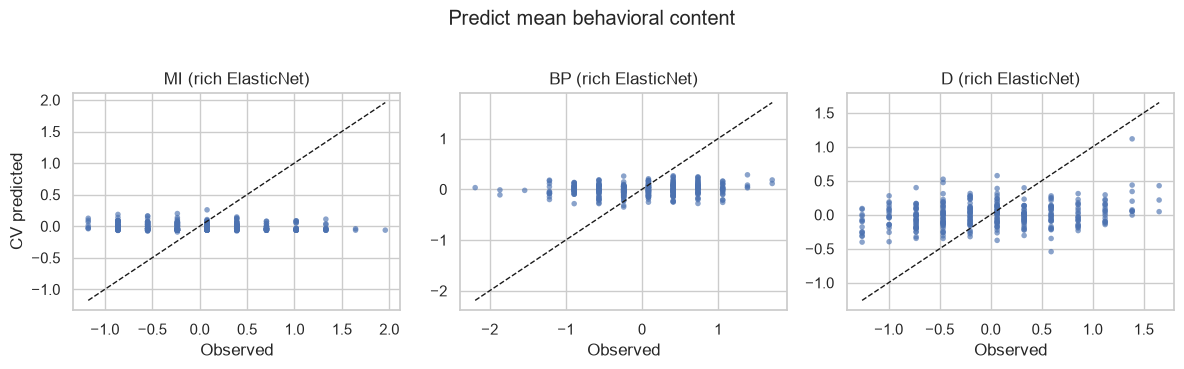

In [6]:
# Plot best feature set (rich) ElasticNet predicted vs observed
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, dim in zip(axes, ["MI", "BP", "D"]):
    y, yhat = content_preds[("rich", "ElasticNet", dim)]
    ax.scatter(y, yhat, s=16, alpha=0.65, edgecolor="none")
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{dim} (rich ElasticNet)")
    ax.set_xlabel("Observed")
axes[0].set_ylabel("CV predicted")
plt.suptitle("Predict mean behavioral content", y=1.02)
plt.tight_layout()
plt.show()

## 4. Which features drive content? (Elastic Net on rich set)

In [7]:
coef_tables = []
for dim_i, dim in enumerate(["MI", "BP", "D"]):
    pipe = make_elastic()
    pipe.fit(X_rich, Y_content[:, dim_i])
    coef = pipe.named_steps["model"].coef_
    tab = pd.DataFrame({"feature": all_feat_cols, "coef": coef, "dim": dim})
    tab["abs_coef"] = tab["coef"].abs()
    coef_tables.append(tab)
    top = tab.sort_values("abs_coef", ascending=False).head(10)
    print(f"\n=== Top coefs for {dim} (alpha={pipe.named_steps['model'].alpha_:.4g}) ===")
    print(top[["feature", "coef"]].round(4).to_string(index=False))

coef_all = pd.concat(coef_tables, ignore_index=True)


=== Top coefs for MI (alpha=0.5736) ===
                feature    coef
              mfcc4_std  0.0240
                chroma7 -0.0191
spectral_bandwidth_mean -0.0095
             mfcc4_mean  0.0094
            mfcc12_mean  0.0049
       mfcc5_delta_mean -0.0035
       mfcc10_delta_std  0.0003
             mfcc7_mean  0.0000
             mfcc2_mean -0.0000
             mfcc1_mean -0.0000



=== Top coefs for BP (alpha=0.5736) ===
                feature    coef
               duration  0.0462
spectral_bandwidth_mean -0.0322
             mfcc4_mean  0.0230
                rms_std  0.0163
                    rms  0.0156
             mfcc2_mean -0.0111
              mfcc4_std  0.0102
                chroma8 -0.0100
       mfcc10_delta_std  0.0098
       mfcc5_delta_mean -0.0076



=== Top coefs for D (alpha=0.0621) ===
   feature    coef
  duration  0.0901
 mfcc4_std  0.0694
   rms_std  0.0507
mfcc4_mean  0.0347
   chroma9 -0.0323
       zcr  0.0163
   chroma7 -0.0145
mfcc5_mean -0.0098
 mfcc8_std  0.0063
mfcc1_mean -0.0000


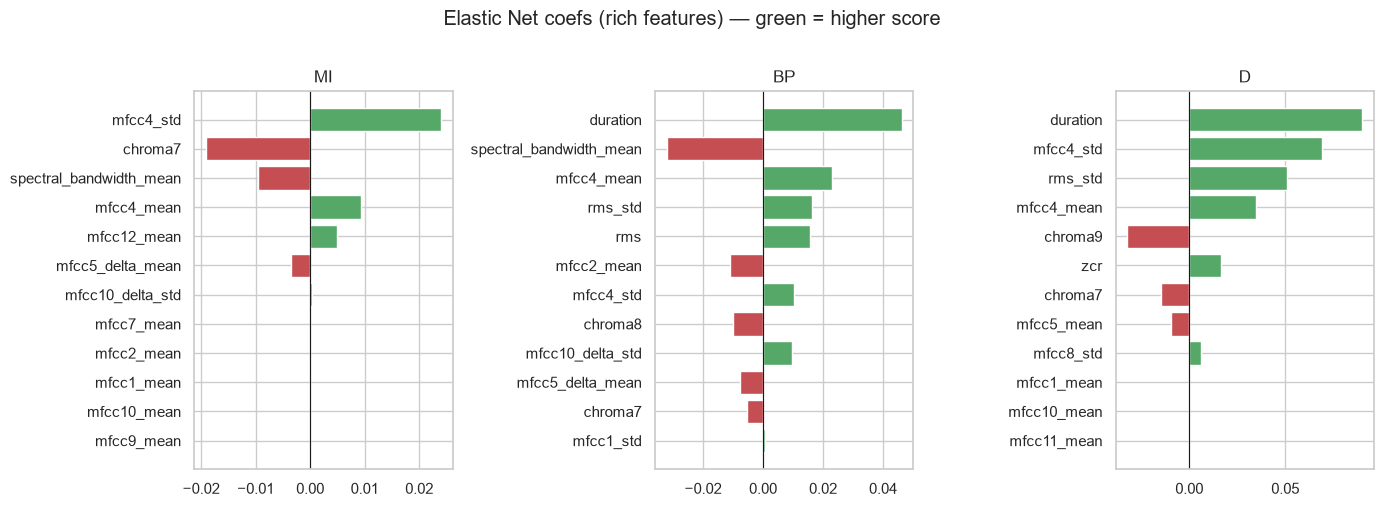

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, dim in zip(axes, ["MI", "BP", "D"]):
    sub = coef_all[coef_all["dim"] == dim].sort_values("abs_coef", ascending=False).head(12).iloc[::-1]
    colors = ["#55A868" if c > 0 else "#C44E52" for c in sub["coef"]]
    ax.barh(sub["feature"], sub["coef"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(dim)
plt.suptitle("Elastic Net coefs (rich features) — green = higher score", y=1.01)
plt.tight_layout()
plt.show()

## 5. Re-test consistency prediction with rich features

In [9]:
cons_rows = []
for feat_name, X in [("base41", X_base), ("rich", X_rich)]:
    for model_name, model in [
        ("Ridge", make_ridge()),
        ("ElasticNet", make_elastic()),
        ("RandomForest", make_rf()),
    ]:
        out = evaluate_cv(model, X, y_euc, groups)
        cons_rows.append({
            "features": feat_name,
            "model": model_name,
            "r2": out["r2"],
            "mae": out["mae"],
            "spearman": out["spearman"],
            "spearman_p": out["spearman_p"],
        })
        print(f"{feat_name:6s} {model_name:12s}: R2={out['r2']:.3f}  Spearman={out['spearman']:.3f} (p={out['spearman_p']:.2e})")

cons_cv = pd.DataFrame(cons_rows)
print("\n", cons_cv.round(4).to_string(index=False))

base41 Ridge       : R2=-0.011  Spearman=0.039 (p=4.96e-01)


base41 ElasticNet  : R2=-0.023  Spearman=-0.045 (p=4.35e-01)


base41 RandomForest: R2=-0.111  Spearman=-0.078 (p=1.72e-01)
rich   Ridge       : R2=-0.000  Spearman=0.066 (p=2.51e-01)


rich   ElasticNet  : R2=-0.018  Spearman=-0.055 (p=3.37e-01)


rich   RandomForest: R2=-0.062  Spearman=-0.030 (p=6.01e-01)

 features        model      r2    mae  spearman  spearman_p
  base41        Ridge -0.0112 0.6903    0.0390      0.4959
  base41   ElasticNet -0.0227 0.6936   -0.0447      0.4354
  base41 RandomForest -0.1106 0.7299   -0.0782      0.1719
    rich        Ridge -0.0004 0.6842    0.0657      0.2507
    rich   ElasticNet -0.0182 0.6925   -0.0549      0.3374
    rich RandomForest -0.0621 0.7098   -0.0300      0.6008


## 6. Do pitch/temporal features alone predict content?

In [10]:
X_temp = df[temporal_cols].to_numpy(dtype=float)
temp_only_rows = []
for model_name, model in [("ElasticNet", make_elastic()), ("RandomForest", make_rf())]:
    for dim_i, dim in enumerate(["MI", "BP", "D"]):
        out = evaluate_cv(model, X_temp, Y_content[:, dim_i], groups)
        temp_only_rows.append({
            "features": "temporal_pitch_only",
            "model": model_name,
            "dim": dim,
            "r2": out["r2"],
            "spearman": out["spearman"],
            "spearman_p": out["spearman_p"],
        })
        print(f"temporal-only {model_name:12s} {dim}: R2={out['r2']:.3f}  Spearman={out['spearman']:.3f}")

temp_only_cv = pd.DataFrame(temp_only_rows)

temporal-only ElasticNet   MI: R2=-0.047  Spearman=-0.237


temporal-only ElasticNet   BP: R2=0.009  Spearman=0.109


temporal-only ElasticNet   D: R2=0.030  Spearman=0.118


temporal-only RandomForest MI: R2=-0.087  Spearman=-0.075


temporal-only RandomForest BP: R2=0.003  Spearman=0.140


temporal-only RandomForest D: R2=0.048  Spearman=0.236


## 7. Save outputs

In [11]:
content_cv.to_csv(OUT_DIR / "behavior_content_cv.csv", index=False)
cons_cv.to_csv(OUT_DIR / "consistency_cv_rich_vs_base.csv", index=False)
temp_only_cv.to_csv(OUT_DIR / "behavior_content_cv_temporal_only.csv", index=False)
coef_all.to_csv(OUT_DIR / "behavior_content_elasticnet_coefs.csv", index=False)

print("=== CONTENT prediction (R2 by dim) ===")
print(content_cv.pivot_table(index=["features", "model"], columns="dim", values=["r2", "spearman"]).round(3))

print("\n=== CONSISTENCY prediction ===")
print(cons_cv.round(4).to_string(index=False))

print("\n=== TEMPORAL/PITCH only (content) ===")
print(temp_only_cv.round(4).to_string(index=False))

print("\nSaved: behavior_content_cv.csv | consistency_cv_rich_vs_base.csv | behavior_content_elasticnet_coefs.csv")

=== CONTENT prediction (R2 by dim) ===
                          r2               spearman              
dim                       BP      D     MI       BP      D     MI
features model                                                   
base41   ElasticNet   -0.005  0.043 -0.055    0.036  0.185 -0.099
         RandomForest -0.025  0.047 -0.071    0.064  0.209 -0.044
         Ridge         0.004  0.052 -0.028    0.086  0.199 -0.043
rich     ElasticNet    0.010  0.056 -0.042    0.100  0.195 -0.172
         RandomForest  0.034  0.053 -0.085    0.157  0.225 -0.087
         Ridge         0.019  0.056 -0.049    0.121  0.204 -0.089

=== CONSISTENCY prediction ===
features        model      r2    mae  spearman  spearman_p
  base41        Ridge -0.0112 0.6903    0.0390      0.4959
  base41   ElasticNet -0.0227 0.6936   -0.0447      0.4354
  base41 RandomForest -0.1106 0.7299   -0.0782      0.1719
    rich        Ridge -0.0004 0.6842    0.0657      0.2507
    rich   ElasticNet -0.0182 0.6925   -